# Geometry — part 5 of 5

This notebook was automatically split from a larger notebook.

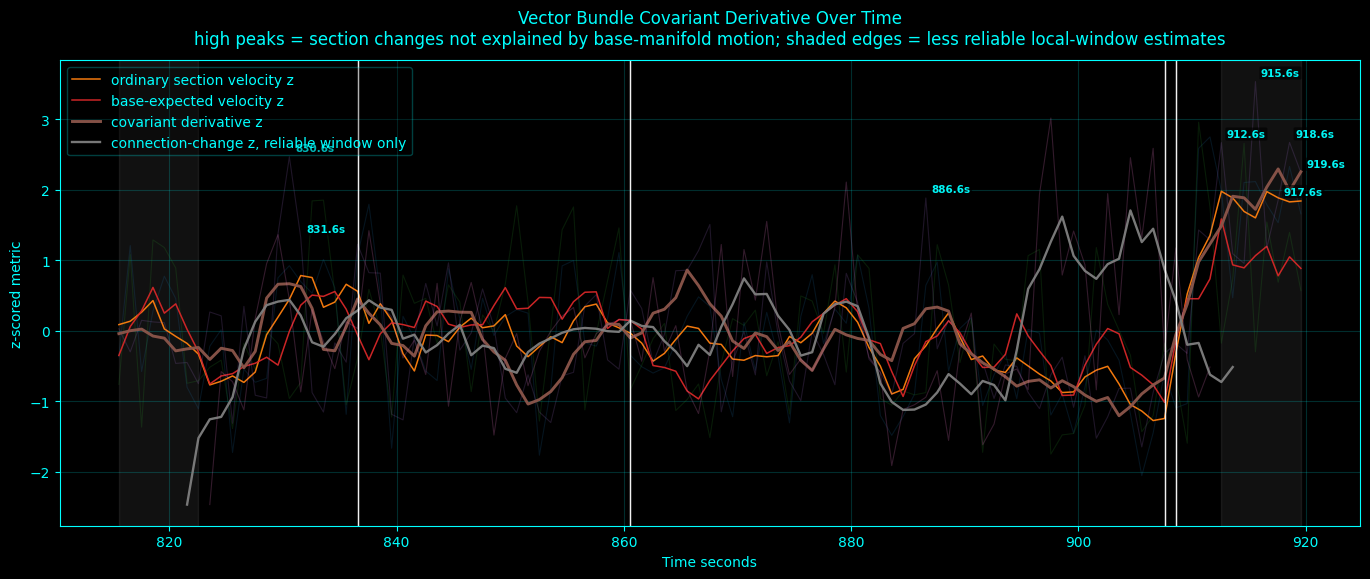

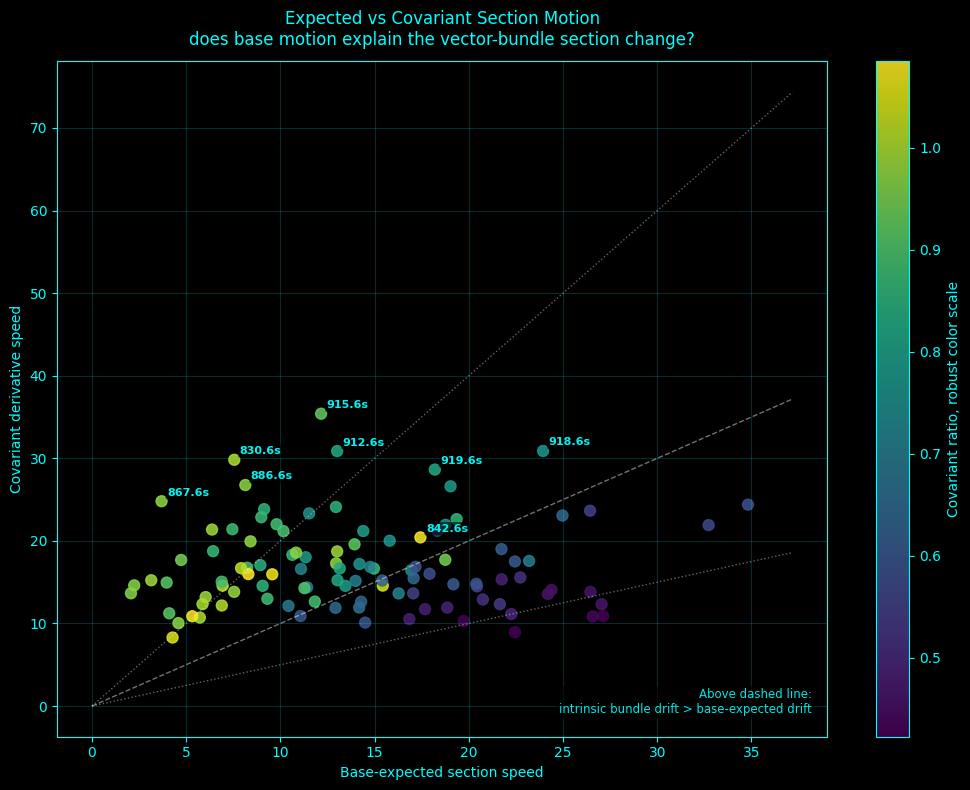

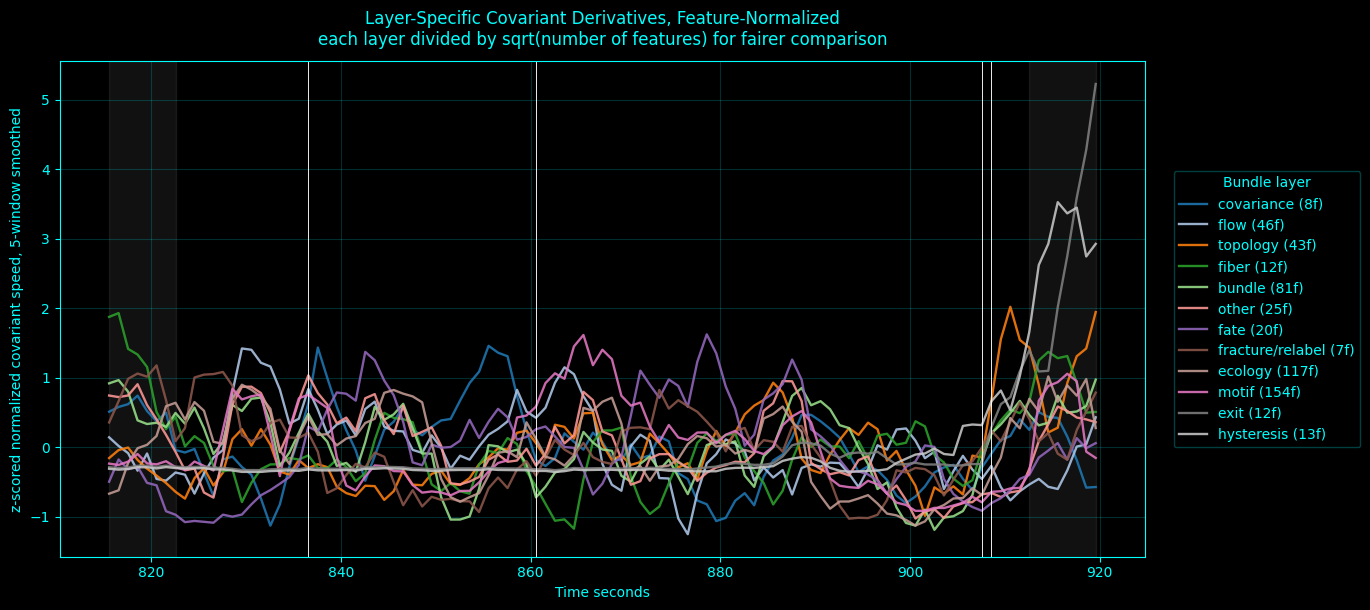

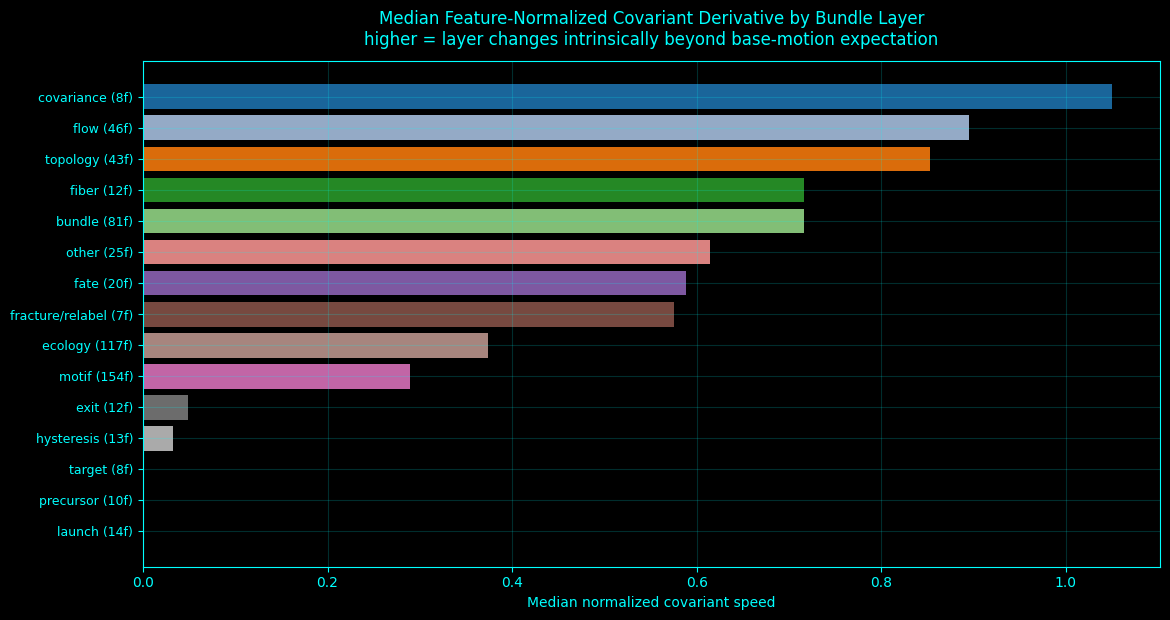

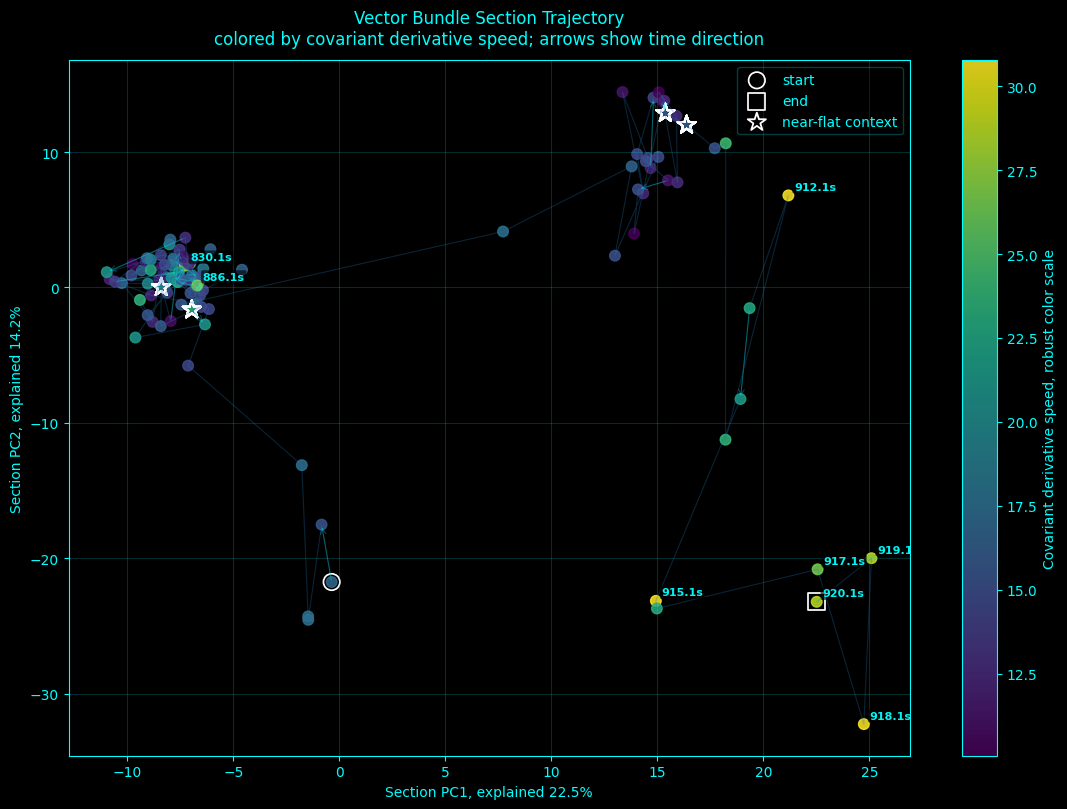

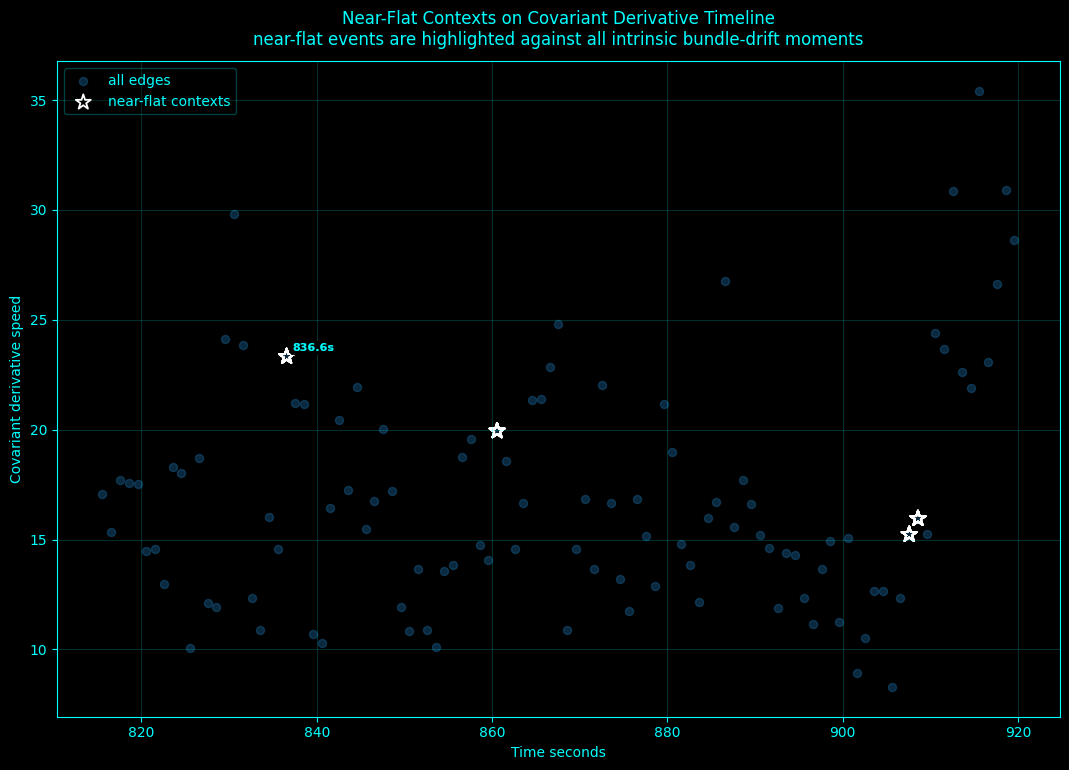

Vector bundle sections saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/vector_bundle_sections.csv
Section metadata saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/vector_bundle_section_feature_metadata.csv
Section principal coordinates saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/section_principal_coordinates.csv
Covariant derivative metrics saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/covariant_derivative_metrics.csv
Layer summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/bundle_layer_summary.csv
Top covariant events saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/top_covariant_events.csv
Near-flat covariant context sav

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eps = 1e-12

base_dir = globals().get("base_dir", "/home/a/projects/Complete-Neural-Signal-Analysis")

ehresmann_dir_candidates = [
    os.path.join(base_dir, "results", "ehresmann_connection_atlas_v2"),
    os.path.join(base_dir, "results", "ehresmann_connection_atlas_v1"),
]

ehresmann_dir = None
for d in ehresmann_dir_candidates:
    if os.path.exists(d):
        ehresmann_dir = d
        break

if ehresmann_dir is None:
    raise FileNotFoundError(
        "Could not find ehresmann_connection_atlas_v2 or ehresmann_connection_atlas_v1. "
        "Run the Ehresmann connection block first."
    )

out_dir = os.path.join(base_dir, "results", "vector_bundle_covariant_derivative_atlas_v2")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if grid:
        ax.grid(True, alpha=0.18, color=ACCENT)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def sanitize_key(s):
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:96] if len(s) else "unnamed"

def short_str(x, max_len=42):
    s = str(x)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    good = np.isfinite(x)
    if not np.any(good):
        return np.zeros_like(x, dtype=float)
    sd = np.nanstd(x[good])
    if not np.isfinite(sd) or sd < 1e-12:
        out[good] = 0.0
        return np.nan_to_num(out, nan=0.0)
    out[good] = (x[good] - np.nanmean(x[good])) / sd
    return out

def robust_fill_numeric_frame(df):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if df[c].notna().any():
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = 0.0
    return df

def standardize_matrix(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[~np.isfinite(sd)] = 1.0
    sd[sd < 1e-12] = 1.0
    Xs = (X - mu) / sd
    Xs[~np.isfinite(Xs)] = 0.0
    return Xs, mu.ravel(), sd.ravel()

def pca_svd(X, n_components=2):
    X = np.asarray(X, dtype=float)
    Xs, mu, sd = standardize_matrix(X)

    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    k = min(n_components, Vt.shape[0])

    scores = U[:, :k] * S[:k]
    components = Vt[:k, :]
    explained = (S ** 2) / max(Xs.shape[0] - 1, 1)

    total = float(np.sum(explained))
    if total > 0:
        explained_ratio = explained[:k] / total
    else:
        explained_ratio = np.zeros(k)

    if k < n_components:
        scores = np.column_stack([scores, np.zeros((scores.shape[0], n_components - k))])
        components = np.vstack([components, np.zeros((n_components - k, Xs.shape[1]))])
        explained_ratio = np.concatenate([explained_ratio, np.zeros(n_components - k)])

    return scores, components, explained_ratio, mu, sd

def nearest_index(source_times, target_times):
    source_times = np.asarray(source_times, dtype=float)
    target_times = np.asarray(target_times, dtype=float)

    if len(source_times) == 0:
        raise ValueError("source_times is empty.")

    if len(source_times) == 1:
        return np.zeros(len(target_times), dtype=int)

    idx = np.searchsorted(source_times, target_times)
    idx = np.clip(idx, 1, len(source_times) - 1)

    left = idx - 1
    right = idx

    choose_right = np.abs(source_times[right] - target_times) < np.abs(source_times[left] - target_times)
    return np.where(choose_right, right, left)

def ridge_solve(X, Y, lam=1e-3):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays.")

    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ Y)

def moving_window_indices(i, n, width):
    half = width // 2
    a = max(0, i - half)
    b = min(n, i + half + 1)

    if b - a < width:
        if a == 0:
            b = min(n, width)
        elif b == n:
            a = max(0, n - width)

    return np.arange(a, b)

def safe_norm_rows(X):
    X = np.asarray(X, dtype=float)
    return np.linalg.norm(X, axis=1)

def annotate_top_points(ax, x, y, labels, scores, top_n=8, dx=4, dy=4, fontsize=8):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(str)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(scores)
    if not np.any(good):
        return

    idx_good = np.where(good)[0]
    order = idx_good[np.argsort(scores[good])[::-1]][:top_n]

    for i in order:
        ax.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=fontsize,
            weight="bold",
            color=ACCENT,
            alpha=0.96,
            bbox=dict(
                facecolor=BG,
                edgecolor="none",
                alpha=0.62,
                boxstyle="round,pad=0.15",
            ),
            clip_on=True,
        )

def robust_scatter_limits(values, q_low=0.02, q_high=0.98):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return None, None
    lo = float(np.quantile(v, q_low))
    hi = float(np.quantile(v, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None, None
    return lo, hi

def rolling_smooth(y, window=5):
    return pd.Series(np.asarray(y, dtype=float)).rolling(window, center=True, min_periods=1).mean().values

def make_unique_name(name, used):
    base = str(name)
    candidate = base
    counter = 2
    while candidate in used:
        candidate = f"{base}__{counter}"
        counter += 1
    used.add(candidate)
    return candidate

base_coord_path = os.path.join(ehresmann_dir, "base_semantic_coordinates.csv")
fiber_coord_path = os.path.join(ehresmann_dir, "fiber_covariance_tangent_coordinates.csv")
connection_path = os.path.join(ehresmann_dir, "connection_metrics_over_time.csv")
label_table_path = os.path.join(ehresmann_dir, "ehresmann_epoch_label_table.csv")
near_connection_path = os.path.join(ehresmann_dir, "near_flat_connection_context.csv")

for p in [base_coord_path, fiber_coord_path, connection_path, label_table_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required Ehresmann output missing: {p}")

base_coord_df = pd.read_csv(base_coord_path)
fiber_coord_df = pd.read_csv(fiber_coord_path)
connection_df = pd.read_csv(connection_path)
label_df = pd.read_csv(label_table_path)

if os.path.exists(near_connection_path):
    near_connection_df = pd.read_csv(near_connection_path)
else:
    near_connection_df = pd.DataFrame()

time_col = "center_time_sec"

base_pc_cols = [c for c in base_coord_df.columns if re.match(r"base_pc\d+", c)]
fiber_pc_cols = [c for c in fiber_coord_df.columns if re.match(r"fiber_pc\d+", c)]

if len(base_pc_cols) < 2:
    raise ValueError("Need at least two base PCs from the Ehresmann atlas.")

if len(fiber_pc_cols) < 2:
    raise ValueError("Need at least two fiber PCs from the Ehresmann atlas.")

base_coord_df = base_coord_df.sort_values(time_col).reset_index(drop=True)
fiber_coord_df = fiber_coord_df.sort_values(time_col).reset_index(drop=True)
label_df = label_df.sort_values(time_col).reset_index(drop=True)

epoch_times = base_coord_df[time_col].values.astype(float)
n_epochs = len(base_coord_df)

B = base_coord_df[base_pc_cols].values.astype(float)
F_cov = fiber_coord_df[fiber_pc_cols].values.astype(float)

if len(fiber_coord_df) != n_epochs or not np.allclose(fiber_coord_df[time_col].values.astype(float), epoch_times, atol=1e-6):
    idx = nearest_index(fiber_coord_df[time_col].values, epoch_times)
    F_cov = fiber_coord_df[fiber_pc_cols].values.astype(float)[idx]

if len(label_df) != n_epochs or not np.allclose(label_df[time_col].values.astype(float), epoch_times, atol=1e-6):
    idx = nearest_index(label_df[time_col].values, epoch_times)
    label_df = label_df.iloc[idx].reset_index(drop=True)

dt = float(np.nanmedian(np.diff(epoch_times))) if len(epoch_times) > 1 else 1.0
if not np.isfinite(dt) or dt <= 0:
    dt = 1.0

preferred_categorical_columns = [
    "dominant_motif",
    "soft_motif",
    "motif_label",
    "ecology_cluster",
    "ecology_name",
    "flow_role",
    "fate_role",
    "topology_name",
    "global_bundle",
    "bundle_role",
    "fiber_role",
    "relabel_stage",
    "fracture_role",
    "hysteresis_role",
    "exit_family",
    "target_family",
    "precursor_cluster",
    "syntax_motif",
    "launch_syntax",
]

def canonical_colname(c):
    s = str(c)
    for p in preferred_categorical_columns:
        if s == p or s.startswith(p + "__"):
            return p
    if "__" in s:
        left = s.split("__")[0]
        for p in preferred_categorical_columns:
            if left == p:
                return p
        return left
    return s

def super_layer_from_column(c):
    canonical = canonical_colname(c).lower()

    if canonical in ["dominant_motif", "soft_motif", "motif_label"]:
        return "motif"
    if canonical in ["ecology_cluster", "ecology_name"]:
        return "ecology"
    if canonical == "flow_role":
        return "flow"
    if canonical == "fate_role":
        return "fate"
    if canonical == "topology_name":
        return "topology"
    if canonical in ["global_bundle", "bundle_role"]:
        return "bundle"
    if canonical == "fiber_role":
        return "fiber"
    if canonical in ["relabel_stage", "fracture_role"]:
        return "fracture/relabel"
    if canonical == "hysteresis_role":
        return "hysteresis"
    if canonical == "exit_family":
        return "exit"
    if canonical in ["syntax_motif", "launch_syntax"]:
        return "launch"
    if canonical == "target_family":
        return "target"
    if canonical == "precursor_cluster":
        return "precursor"

    s = str(c).lower()
    if "motif" in s:
        return "motif"
    if "ecology" in s:
        return "ecology"
    if "flow" in s:
        return "flow"
    if "fate" in s:
        return "fate"
    if "topology" in s or "lobe" in s:
        return "topology"
    if "bundle" in s:
        return "bundle"
    if "fiber" in s:
        return "fiber"
    if "relabel" in s or "fracture" in s:
        return "fracture/relabel"
    if "hysteresis" in s:
        return "hysteresis"
    if "exit" in s:
        return "exit"
    if "launch" in s or "syntax" in s:
        return "launch"
    if "target" in s:
        return "target"
    if "precursor" in s:
        return "precursor"

    return "other"

candidate_categorical_cols = []

for c in label_df.columns:
    if c in ["epoch_index", "center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        continue

    nunique = label_df[c].dropna().nunique()
    canonical = canonical_colname(c)

    if canonical in preferred_categorical_columns and 2 <= nunique <= 40:
        candidate_categorical_cols.append(c)

candidate_categorical_cols = sorted(set(candidate_categorical_cols))

numeric_bundle_hints = [
    "drift",
    "entropy",
    "purity",
    "consensus",
    "pressure",
    "score",
    "velocity",
    "speed",
    "branchiness",
    "dispersion",
    "radius",
    "distance",
    "curvature",
    "hysteresis",
    "loop",
    "relabel",
    "fracture",
    "future",
    "flow",
    "bundle",
    "fiber",
    "exit",
    "syntax",
    "launch",
]

candidate_numeric_cols = []

for c in label_df.columns:
    if c in ["epoch_index", "center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        continue

    if pd.api.types.is_numeric_dtype(label_df[c]):
        nunique = label_df[c].dropna().nunique()
        hint = any(h in c.lower() for h in numeric_bundle_hints)
        if hint and nunique >= 3:
            candidate_numeric_cols.append(c)

candidate_numeric_cols = sorted(set(candidate_numeric_cols))

feature_arrays = []
feature_names = []
section_feature_meta = []
used_feature_names = set()

def add_section_feature(name, values, section_type, source_column, canonical_column, super_layer):
    values = np.asarray(values, dtype=float).reshape(-1)

    if len(values) != n_epochs:
        raise ValueError(f"Feature {name} length {len(values)} does not match n_epochs={n_epochs}")

    clean_name = make_unique_name(name, used_feature_names)

    feature_names.append(clean_name)
    feature_arrays.append(values)

    section_feature_meta.append({
        "section_feature": clean_name,
        "section_type": section_type,
        "source_column": source_column,
        "canonical_column": canonical_column,
        "super_layer": super_layer,
    })

for k, c in enumerate(fiber_pc_cols):
    add_section_feature(
        name=f"covariance_fiber::{c}",
        values=F_cov[:, k],
        section_type="covariance_tangent",
        source_column=c,
        canonical_column="covariance_fiber",
        super_layer="covariance",
    )

for c in candidate_categorical_cols:
    values = label_df[c].astype(str).fillna("missing")
    unique_vals = sorted(values.dropna().unique().tolist(), key=lambda x: str(x))

    if len(unique_vals) < 2:
        continue

    for val in unique_vals:
        dummy = (values == val).astype(float).values
        add_section_feature(
            name=f"cat::{sanitize_key(c)}::{sanitize_key(val)}",
            values=dummy,
            section_type="categorical_onehot",
            source_column=c,
            canonical_column=canonical_colname(c),
            super_layer=super_layer_from_column(c),
        )

if candidate_numeric_cols:
    numeric_df = robust_fill_numeric_frame(label_df[candidate_numeric_cols])
    numeric_X, _, _ = standardize_matrix(numeric_df.values.astype(float))

    for j, c in enumerate(candidate_numeric_cols):
        add_section_feature(
            name=f"num::{sanitize_key(c)}",
            values=numeric_X[:, j],
            section_type="numeric_scalar",
            source_column=c,
            canonical_column=canonical_colname(c),
            super_layer=super_layer_from_column(c),
        )

if not feature_arrays:
    raise ValueError("No vector-bundle section features found.")

S_raw = np.column_stack(feature_arrays)
S, section_mu, section_sd = standardize_matrix(S_raw)

section_df = pd.DataFrame(S, columns=feature_names)
section_df.insert(0, "center_time_sec", epoch_times)
section_df.insert(0, "epoch_index", np.arange(n_epochs))

section_meta_df = pd.DataFrame(section_feature_meta)

section_csv = os.path.join(out_dir, "vector_bundle_sections.csv")
section_df.to_csv(section_csv, index=False)

section_meta_csv = os.path.join(out_dir, "vector_bundle_section_feature_metadata.csv")
section_meta_df.to_csv(section_meta_csv, index=False)

bundle_scores, bundle_components, bundle_explained, bundle_mu, bundle_sd = pca_svd(
    S,
    n_components=min(12, S.shape[1], n_epochs),
)

bundle_coord_df = pd.DataFrame({
    "epoch_index": np.arange(n_epochs),
    "center_time_sec": epoch_times,
})

for k in range(bundle_scores.shape[1]):
    bundle_coord_df[f"section_pc{k+1}"] = bundle_scores[:, k]

bundle_coord_csv = os.path.join(out_dir, "section_principal_coordinates.csv")
bundle_coord_df.to_csv(bundle_coord_csv, index=False)

dB = np.diff(B, axis=0) / dt
dS = np.diff(S, axis=0) / dt
dQ = np.diff(bundle_scores, axis=0) / dt

n_edges = len(dB)
edge_times = 0.5 * (epoch_times[:-1] + epoch_times[1:])

ridge_lambda = 1e-3
local_window = 17
min_local_rows = 8
edge_margin = local_window // 2

if n_edges > 2 * edge_margin:
    edge_reliable = np.zeros(n_edges, dtype=bool)
    edge_reliable[edge_margin:n_edges - edge_margin] = True
else:
    edge_reliable = np.ones(n_edges, dtype=bool)

A_global_section = ridge_solve(dB, dS, lam=ridge_lambda)
dS_expected_global = dB @ A_global_section
dS_covariant_global = dS - dS_expected_global

A_local_section = np.zeros((n_edges, dB.shape[1], dS.shape[1]), dtype=float)
dS_expected = np.zeros_like(dS)
dS_covariant = np.zeros_like(dS)

for i in range(n_edges):
    idx = moving_window_indices(i, n_edges, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dS[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global_section.copy()
    else:
        A_i = A_global_section.copy()

    A_local_section[i] = A_i
    dS_expected[i] = dB[i] @ A_i
    dS_covariant[i] = dS[i] - dS_expected[i]

A_global_pc = ridge_solve(dB, dQ, lam=ridge_lambda)
dQ_expected_global = dB @ A_global_pc
dQ_covariant_global = dQ - dQ_expected_global

A_local_pc = np.zeros((n_edges, dB.shape[1], dQ.shape[1]), dtype=float)
dQ_expected = np.zeros_like(dQ)
dQ_covariant = np.zeros_like(dQ)

for i in range(n_edges):
    idx = moving_window_indices(i, n_edges, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dQ[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global_pc.copy()
    else:
        A_i = A_global_pc.copy()

    A_local_pc[i] = A_i
    dQ_expected[i] = dB[i] @ A_i
    dQ_covariant[i] = dQ[i] - dQ_expected[i]

ordinary_section_speed = safe_norm_rows(dS)
expected_section_speed = safe_norm_rows(dS_expected)
covariant_section_speed = safe_norm_rows(dS_covariant)
covariant_ratio = covariant_section_speed / (ordinary_section_speed + eps)
connection_explained_fraction = expected_section_speed / (ordinary_section_speed + expected_section_speed + eps)

ordinary_pc_speed = safe_norm_rows(dQ)
expected_pc_speed = safe_norm_rows(dQ_expected)
covariant_pc_speed = safe_norm_rows(dQ_covariant)
covariant_pc_ratio = covariant_pc_speed / (ordinary_pc_speed + eps)

base_speed = safe_norm_rows(dB)

connection_norm_section = safe_norm_rows(A_local_section.reshape(n_edges, -1))
connection_norm_pc = safe_norm_rows(A_local_pc.reshape(n_edges, -1))

connection_change_section = np.zeros(n_edges)
connection_change_pc = np.zeros(n_edges)

for i in range(1, n_edges):
    connection_change_section[i] = np.linalg.norm(A_local_section[i] - A_local_section[i - 1], ord="fro")
    connection_change_pc[i] = np.linalg.norm(A_local_pc[i] - A_local_pc[i - 1], ord="fro")

connection_change_section_log = np.log1p(connection_change_section)
connection_change_pc_log = np.log1p(connection_change_pc)

connection_change_section_log_reliable = connection_change_section_log.copy()
connection_change_pc_log_reliable = connection_change_pc_log.copy()
connection_change_section_log_reliable[~edge_reliable] = np.nan
connection_change_pc_log_reliable[~edge_reliable] = np.nan

covariant_acceleration = np.zeros(n_edges)
ordinary_acceleration = np.zeros(n_edges)

if n_edges > 1:
    covariant_acceleration[1:] = safe_norm_rows(np.diff(dS_covariant, axis=0)) / dt
    ordinary_acceleration[1:] = safe_norm_rows(np.diff(dS, axis=0)) / dt

layer_names = section_meta_df["super_layer"].astype(str).values
unique_layers = sorted(set(layer_names))

layer_covariant = {}
layer_ordinary = {}
layer_expected = {}
layer_ratio = {}
layer_covariant_normed = {}
layer_ordinary_normed = {}
layer_expected_normed = {}
layer_ratio_normed = {}
layer_feature_count = {}

for layer in unique_layers:
    idx = np.where(layer_names == layer)[0]
    if len(idx) == 0:
        continue

    denom = math.sqrt(max(len(idx), 1))
    layer_feature_count[layer] = int(len(idx))

    layer_covariant[layer] = safe_norm_rows(dS_covariant[:, idx])
    layer_ordinary[layer] = safe_norm_rows(dS[:, idx])
    layer_expected[layer] = safe_norm_rows(dS_expected[:, idx])
    layer_ratio[layer] = layer_covariant[layer] / (layer_ordinary[layer] + eps)

    layer_covariant_normed[layer] = layer_covariant[layer] / denom
    layer_ordinary_normed[layer] = layer_ordinary[layer] / denom
    layer_expected_normed[layer] = layer_expected[layer] / denom
    layer_ratio_normed[layer] = layer_covariant_normed[layer] / (layer_ordinary_normed[layer] + eps)

metrics_dict = {
    "edge_index": np.arange(n_edges),
    "start_epoch_index": np.arange(n_edges),
    "end_epoch_index": np.arange(1, n_epochs),
    "center_time_sec": edge_times,
    "start_time_sec": epoch_times[:-1],
    "end_time_sec": epoch_times[1:],
    "edge_reliable": edge_reliable,
    "base_speed": base_speed,
    "ordinary_section_speed": ordinary_section_speed,
    "expected_section_speed": expected_section_speed,
    "covariant_section_speed": covariant_section_speed,
    "covariant_ratio": covariant_ratio,
    "connection_explained_fraction": connection_explained_fraction,
    "ordinary_pc_speed": ordinary_pc_speed,
    "expected_pc_speed": expected_pc_speed,
    "covariant_pc_speed": covariant_pc_speed,
    "covariant_pc_ratio": covariant_pc_ratio,
    "ordinary_acceleration": ordinary_acceleration,
    "covariant_acceleration": covariant_acceleration,
    "connection_norm_section": connection_norm_section,
    "connection_change_section": connection_change_section,
    "connection_change_section_log": connection_change_section_log,
    "connection_change_section_log_reliable": connection_change_section_log_reliable,
    "connection_norm_pc": connection_norm_pc,
    "connection_change_pc": connection_change_pc,
    "connection_change_pc_log": connection_change_pc_log,
    "connection_change_pc_log_reliable": connection_change_pc_log_reliable,
}

for layer in unique_layers:
    safe_layer = sanitize_key(layer)
    metrics_dict[f"{safe_layer}_feature_count"] = np.full(n_edges, layer_feature_count[layer], dtype=int)
    metrics_dict[f"{safe_layer}_ordinary_speed_raw"] = layer_ordinary[layer]
    metrics_dict[f"{safe_layer}_expected_speed_raw"] = layer_expected[layer]
    metrics_dict[f"{safe_layer}_covariant_speed_raw"] = layer_covariant[layer]
    metrics_dict[f"{safe_layer}_covariant_ratio_raw"] = layer_ratio[layer]
    metrics_dict[f"{safe_layer}_ordinary_speed_normed"] = layer_ordinary_normed[layer]
    metrics_dict[f"{safe_layer}_expected_speed_normed"] = layer_expected_normed[layer]
    metrics_dict[f"{safe_layer}_covariant_speed_normed"] = layer_covariant_normed[layer]
    metrics_dict[f"{safe_layer}_covariant_ratio_normed"] = layer_ratio_normed[layer]

for k in range(min(bundle_scores.shape[1], 8)):
    metrics_dict[f"section_pc{k+1}_velocity"] = dQ[:, k]
    metrics_dict[f"section_pc{k+1}_expected_velocity"] = dQ_expected[:, k]
    metrics_dict[f"section_pc{k+1}_covariant_derivative"] = dQ_covariant[:, k]

metrics_df = pd.DataFrame(metrics_dict)

near_times = []

if len(near_connection_df):
    near_time_col = None
    for c in ["nearest_connection_time_sec", "event_time_sec", "center_time_sec"]:
        if c in near_connection_df.columns:
            near_time_col = c
            break

    if near_time_col is not None:
        near_times = near_connection_df[near_time_col].dropna().values.astype(float)

near_flag = np.zeros(n_edges, dtype=bool)

if len(near_times):
    near_idx = nearest_index(edge_times, near_times)
    near_flag[near_idx] = True

metrics_df["near_flat_associated"] = near_flag

metrics_csv = os.path.join(out_dir, "covariant_derivative_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

np.savez_compressed(
    os.path.join(out_dir, "section_connection_matrices.npz"),
    A_global_section=A_global_section,
    A_local_section=A_local_section,
    A_global_pc=A_global_pc,
    A_local_pc=A_local_pc,
    bundle_components=bundle_components,
    bundle_explained=bundle_explained,
    bundle_mu=bundle_mu,
    bundle_sd=bundle_sd,
    section_mu=section_mu,
    section_sd=section_sd,
    feature_names=np.array(feature_names, dtype=object),
    base_pc_cols=np.array(base_pc_cols, dtype=object),
    edge_reliable=edge_reliable,
)

layer_summary_rows = []

for layer in unique_layers:
    safe_layer = sanitize_key(layer)

    raw_cov_col = f"{safe_layer}_covariant_speed_raw"
    raw_ratio_col = f"{safe_layer}_covariant_ratio_raw"
    norm_cov_col = f"{safe_layer}_covariant_speed_normed"
    norm_ratio_col = f"{safe_layer}_covariant_ratio_normed"

    reliable_df = metrics_df[metrics_df["edge_reliable"]].copy()
    if len(reliable_df) == 0:
        reliable_df = metrics_df.copy()

    row = {
        "super_layer": layer,
        "n_features": layer_feature_count[layer],
        "median_covariant_speed_raw": float(np.nanmedian(reliable_df[raw_cov_col])),
        "median_covariant_ratio_raw": float(np.nanmedian(reliable_df[raw_ratio_col])),
        "max_covariant_speed_raw": float(np.nanmax(reliable_df[raw_cov_col])),
        "median_covariant_speed_normed": float(np.nanmedian(reliable_df[norm_cov_col])),
        "median_covariant_ratio_normed": float(np.nanmedian(reliable_df[norm_ratio_col])),
        "max_covariant_speed_normed": float(np.nanmax(reliable_df[norm_cov_col])),
    }

    if metrics_df["near_flat_associated"].any():
        nf = metrics_df[metrics_df["near_flat_associated"]]
        row["near_flat_median_covariant_speed_normed"] = float(np.nanmedian(nf[norm_cov_col]))
        row["near_flat_median_covariant_ratio_normed"] = float(np.nanmedian(nf[norm_ratio_col]))
    else:
        row["near_flat_median_covariant_speed_normed"] = np.nan
        row["near_flat_median_covariant_ratio_normed"] = np.nan

    layer_summary_rows.append(row)

layer_summary_df = pd.DataFrame(layer_summary_rows).sort_values("median_covariant_speed_normed", ascending=False)
layer_summary_csv = os.path.join(out_dir, "bundle_layer_summary.csv")
layer_summary_df.to_csv(layer_summary_csv, index=False)

event_rows = []

event_specs = [
    ("global_covariant_speed", "covariant_section_speed"),
    ("global_covariant_ratio", "covariant_ratio"),
    ("section_pc_covariant_speed", "covariant_pc_speed"),
    ("covariant_acceleration", "covariant_acceleration"),
    ("connection_change_reliable", "connection_change_section_log_reliable"),
]

for event_type, col in event_specs:
    event_base_df = metrics_df.copy()
    if col == "connection_change_section_log_reliable":
        event_base_df = event_base_df[event_base_df["edge_reliable"]].copy()

    top = event_base_df.sort_values(col, ascending=False).head(15)

    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": event_type,
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "edge_reliable": bool(r["edge_reliable"]),
            "base_speed": float(r["base_speed"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "near_flat_associated": bool(r["near_flat_associated"]),
        })

for layer in unique_layers:
    safe_layer = sanitize_key(layer)
    col = f"{safe_layer}_covariant_speed_normed"
    if col not in metrics_df.columns:
        continue

    top = metrics_df[metrics_df["edge_reliable"]].sort_values(col, ascending=False).head(8)

    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": f"layer_{safe_layer}_covariant_speed_normed",
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "edge_reliable": bool(r["edge_reliable"]),
            "base_speed": float(r["base_speed"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "near_flat_associated": bool(r["near_flat_associated"]),
        })

top_events_df = pd.DataFrame(event_rows)
top_events_csv = os.path.join(out_dir, "top_covariant_events.csv")
top_events_df.to_csv(top_events_csv, index=False)

near_cov_rows = []

if len(near_times):
    idxs = nearest_index(metrics_df["center_time_sec"].values, near_times)

    for j, edge_i in enumerate(idxs):
        r = metrics_df.iloc[int(edge_i)]

        row = {
            "near_flat_index": int(j),
            "event_time_sec": float(near_times[j]),
            "nearest_edge_index": int(r["edge_index"]),
            "nearest_covariant_time_sec": float(r["center_time_sec"]),
            "edge_reliable": bool(r["edge_reliable"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_pc_speed": float(r["covariant_pc_speed"]),
            "covariant_pc_ratio": float(r["covariant_pc_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "connection_change_section_log_reliable": float(r["connection_change_section_log_reliable"]) if np.isfinite(r["connection_change_section_log_reliable"]) else np.nan,
        }

        for layer in unique_layers:
            safe_layer = sanitize_key(layer)
            col = f"{safe_layer}_covariant_speed_normed"
            if col in metrics_df.columns:
                row[f"{safe_layer}_covariant_speed_normed"] = float(r[col])

        near_cov_rows.append(row)

near_cov_df = pd.DataFrame(near_cov_rows)
near_cov_csv = os.path.join(out_dir, "near_flat_covariant_context.csv")
near_cov_df.to_csv(near_cov_csv, index=False)

layer_order = layer_summary_df["super_layer"].tolist()

try:
    cmap = plt.colormaps["tab20"].resampled(max(len(layer_order), 1))
except Exception:
    cmap = plt.get_cmap("tab20", max(len(layer_order), 1))

layer_color = {layer: cmap(i) for i, layer in enumerate(layer_order)}

fig, ax = plt.subplots(figsize=(13.8, 5.9))

edge_t = metrics_df["center_time_sec"].values

ordinary_z = zscore_safe(metrics_df["ordinary_section_speed"].values)
expected_z = zscore_safe(metrics_df["expected_section_speed"].values)
covariant_z = zscore_safe(metrics_df["covariant_section_speed"].values)

conn_change = metrics_df["connection_change_section_log_reliable"].values
conn_change_z = zscore_safe(conn_change)

plot_specs = [
    (ordinary_z, "ordinary section velocity z", 1.1, 0.38),
    (expected_z, "base-expected velocity z", 1.1, 0.38),
    (covariant_z, "covariant derivative z", 2.1, 0.46),
    (conn_change_z, "connection-change z, reliable window only", 1.7, 0.50),
]

for y, label, lw, raw_alpha in plot_specs:
    ax.plot(edge_t, y, alpha=raw_alpha * 0.45, linewidth=0.8)
    ax.plot(edge_t, rolling_smooth(y, 5), label=label, linewidth=lw, alpha=0.95)

if not np.all(edge_reliable):
    unreliable_left = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] < edge_margin)]
    unreliable_right = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] >= n_edges - edge_margin)]

    if len(unreliable_left):
        ax.axvspan(unreliable_left["center_time_sec"].min(), unreliable_left["center_time_sec"].max(), color="white", alpha=0.07)
    if len(unreliable_right):
        ax.axvspan(unreliable_right["center_time_sec"].min(), unreliable_right["center_time_sec"].max(), color="white", alpha=0.07)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.20, linewidth=0.85)

labels = np.array([f"{t:.1f}s" for t in edge_t])
score = zscore_safe(metrics_df["covariant_section_speed"].values) + 0.45 * zscore_safe(metrics_df["covariant_acceleration"].values)
annotate_top_points(
    ax,
    edge_t,
    covariant_z,
    labels,
    score,
    top_n=8,
    fontsize=7.5,
)

style_ax(ax)
ax.set_title(
    "Vector Bundle Covariant Derivative Over Time\n"
    "high peaks = section changes not explained by base-manifold motion; shaded edges = less reliable local-window estimates",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored metric")
ax.legend(framealpha=0.25, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_covariant_derivative_over_time.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10.4, 8.0))

color_values = metrics_df["covariant_ratio"].values
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    metrics_df["expected_section_speed"],
    metrics_df["covariant_section_speed"],
    c=color_values,
    s=62,
    alpha=0.86,
    vmin=vmin,
    vmax=vmax,
)

max_axis = float(np.nanmax([
    metrics_df["expected_section_speed"].max(),
    metrics_df["covariant_section_speed"].max(),
]))

if np.isfinite(max_axis) and max_axis > 0:
    xs = np.linspace(0, max_axis * 1.05, 200)
    ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)
    ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)

ax.text(
    0.98,
    0.03,
    "Above dashed line:\nintrinsic bundle drift > base-expected drift",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    alpha=0.90,
    bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
)

labels = np.array([f"{t:.1f}s" for t in metrics_df["center_time_sec"].values])
score = zscore_safe(metrics_df["covariant_section_speed"].values) + zscore_safe(metrics_df["covariant_ratio"].values)
annotate_top_points(
    ax,
    metrics_df["expected_section_speed"].values,
    metrics_df["covariant_section_speed"].values,
    labels,
    score,
    top_n=8,
    fontsize=8,
)

style_ax(ax)
ax.set_title(
    "Expected vs Covariant Section Motion\n"
    "does base motion explain the vector-bundle section change?",
    pad=12,
)
ax.set_xlabel("Base-expected section speed")
ax.set_ylabel("Covariant derivative speed")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("Covariant ratio, robust color scale", color=ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_expected_vs_covariant_section_motion.png"), dpi=260, bbox_inches="tight")
plt.show()

plot_layers = layer_summary_df.head(min(12, len(layer_summary_df)))["super_layer"].tolist()

fig, ax = plt.subplots(figsize=(13.8, 6.2))

for layer in plot_layers:
    safe_layer = sanitize_key(layer)
    col = f"{safe_layer}_covariant_speed_normed"
    if col not in metrics_df.columns:
        continue

    y = zscore_safe(metrics_df[col].values)
    y_smooth = rolling_smooth(y, 5)

    ax.plot(
        metrics_df["center_time_sec"],
        y_smooth,
        label=f"{layer} ({layer_feature_count[layer]}f)",
        linewidth=1.7,
        alpha=0.88,
        color=layer_color.get(layer, None),
    )

if not np.all(edge_reliable):
    unreliable_left = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] < edge_margin)]
    unreliable_right = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] >= n_edges - edge_margin)]

    if len(unreliable_left):
        ax.axvspan(unreliable_left["center_time_sec"].min(), unreliable_left["center_time_sec"].max(), color="white", alpha=0.07)
    if len(unreliable_right):
        ax.axvspan(unreliable_right["center_time_sec"].min(), unreliable_right["center_time_sec"].max(), color="white", alpha=0.07)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.16, linewidth=0.75)

style_ax(ax)
ax.set_title(
    "Layer-Specific Covariant Derivatives, Feature-Normalized\n"
    "each layer divided by sqrt(number of features) for fairer comparison",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored normalized covariant speed, 5-window smoothed")
ax.legend(framealpha=0.25, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Bundle layer")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_layer_specific_covariant_derivatives_feature_normalized.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11.8, max(5.8, 0.42 * len(layer_summary_df))))

plot_df = layer_summary_df.sort_values("median_covariant_speed_normed", ascending=True).copy()
bar_colors = [layer_color.get(layer, (0.6, 0.6, 0.6, 1.0)) for layer in plot_df["super_layer"]]
labels = [
    f"{row.super_layer} ({int(row.n_features)}f)"
    for _, row in plot_df.iterrows()
]

ax.barh(
    np.arange(len(plot_df)),
    plot_df["median_covariant_speed_normed"].values,
    alpha=0.86,
    color=bar_colors,
)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(labels, fontsize=9)

style_ax(ax)
ax.set_title(
    "Median Feature-Normalized Covariant Derivative by Bundle Layer\n"
    "higher = layer changes intrinsically beyond base-motion expectation",
    pad=12,
)
ax.set_xlabel("Median normalized covariant speed")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_bundle_layer_median_covariant_speed_normalized.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11.4, 8.2))

if bundle_scores.shape[1] >= 2:
    color_values = np.r_[metrics_df["covariant_section_speed"].values, metrics_df["covariant_section_speed"].values[-1]]
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        bundle_scores[:, 0],
        bundle_scores[:, 1],
        c=color_values,
        s=58,
        alpha=0.86,
        vmin=vmin,
        vmax=vmax,
    )

    ax.plot(bundle_scores[:, 0], bundle_scores[:, 1], linewidth=0.8, alpha=0.30)

    ax.scatter(
        bundle_scores[0, 0],
        bundle_scores[0, 1],
        s=140,
        marker="o",
        facecolors="none",
        edgecolors="white",
        linewidths=1.25,
        label="start",
    )

    ax.scatter(
        bundle_scores[-1, 0],
        bundle_scores[-1, 1],
        s=150,
        marker="s",
        facecolors="none",
        edgecolors="white",
        linewidths=1.25,
        label="end",
    )

    step = max(1, n_epochs // 14)
    for i in range(0, n_epochs - 1, step):
        ax.annotate(
            "",
            xy=(bundle_scores[i + 1, 0], bundle_scores[i + 1, 1]),
            xytext=(bundle_scores[i, 0], bundle_scores[i, 1]),
            arrowprops=dict(arrowstyle="->", color=ACCENT, alpha=0.28, lw=0.8),
        )

    if len(near_times):
        near_idx = nearest_index(epoch_times, near_times)
        ax.scatter(
            bundle_scores[near_idx, 0],
            bundle_scores[near_idx, 1],
            s=190,
            marker="*",
            facecolors="none",
            edgecolors="white",
            linewidths=1.3,
            label="near-flat context",
        )

    labels = np.array([f"{t:.1f}s" for t in epoch_times])
    score = np.r_[metrics_df["covariant_section_speed"].values, metrics_df["covariant_section_speed"].values[-1]]
    annotate_top_points(
        ax,
        bundle_scores[:, 0],
        bundle_scores[:, 1],
        labels,
        score,
        top_n=8,
        fontsize=8,
    )

    style_ax(ax)
    ax.set_title(
        "Vector Bundle Section Trajectory\n"
        "colored by covariant derivative speed; arrows show time direction",
        pad=12,
    )
    ax.set_xlabel(f"Section PC1, explained {100 * bundle_explained[0]:.1f}%")
    ax.set_ylabel(f"Section PC2, explained {100 * bundle_explained[1]:.1f}%")

    ax.legend(framealpha=0.25)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Covariant derivative speed, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "v2_section_trajectory_colored_by_covariant_speed.png"), dpi=260, bbox_inches="tight")
    plt.show()

if len(near_cov_df):
    fig, ax = plt.subplots(figsize=(10.8, 7.8))

    ax.scatter(
        metrics_df["center_time_sec"],
        metrics_df["covariant_section_speed"],
        s=34,
        alpha=0.35,
        label="all edges",
    )

    ax.scatter(
        near_cov_df["nearest_covariant_time_sec"],
        near_cov_df["covariant_section_speed"],
        s=130,
        marker="*",
        facecolors="none",
        edgecolors="white",
        linewidths=1.3,
        label="near-flat contexts",
    )

    reliable_near = near_cov_df[near_cov_df["edge_reliable"]]
    if len(reliable_near):
        annotate_top_points(
            ax,
            reliable_near["nearest_covariant_time_sec"].values,
            reliable_near["covariant_section_speed"].values,
            np.array([f"{t:.1f}s" for t in reliable_near["nearest_covariant_time_sec"].values]),
            reliable_near["covariant_section_speed"].values,
            top_n=min(6, len(reliable_near)),
            fontsize=8,
        )

    style_ax(ax)
    ax.set_title(
        "Near-Flat Contexts on Covariant Derivative Timeline\n"
        "near-flat events are highlighted against all intrinsic bundle-drift moments",
        pad=12,
    )
    ax.set_xlabel("Time seconds")
    ax.set_ylabel("Covariant derivative speed")
    ax.legend(framealpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "v2_near_flat_covariant_derivative_context.png"), dpi=260, bbox_inches="tight")
    plt.show()

summary_txt = os.path.join(out_dir, "covariant_derivative_summary.txt")

reliable_metrics = metrics_df[metrics_df["edge_reliable"]].copy()
if len(reliable_metrics) == 0:
    reliable_metrics = metrics_df.copy()

top_cov = reliable_metrics.sort_values("covariant_section_speed", ascending=False).head(15)
top_ratio = reliable_metrics.sort_values("covariant_ratio", ascending=False).head(15)
top_acc = reliable_metrics.sort_values("covariant_acceleration", ascending=False).head(15)

with open(summary_txt, "w") as f:
    f.write("Vector Bundles and Covariant Derivatives Atlas v2\n")
    f.write("=================================================\n\n")

    f.write("Conceptual mapping:\n")
    f.write("  Base = semantic manifold trajectory from the Ehresmann atlas.\n")
    f.write("  Bundle section = covariance / semantic / event vector attached to each base point.\n")
    f.write("  Ordinary derivative = raw change of the section over time.\n")
    f.write("  Connection = local ridge map predicting section change from base velocity.\n")
    f.write("  Covariant derivative = section change minus the base-predicted change.\n")
    f.write("  High covariant derivative = intrinsic drift of the attached object, not explained by base movement.\n\n")

    f.write(f"Ehresmann source directory = {ehresmann_dir}\n")
    f.write(f"n_epochs = {n_epochs}\n")
    f.write(f"n_edges = {n_edges}\n")
    f.write(f"dt = {dt:.6f}\n")
    f.write(f"n_section_features = {len(feature_names)}\n")
    f.write(f"n_categorical_columns = {len(candidate_categorical_cols)}\n")
    f.write(f"n_numeric_columns = {len(candidate_numeric_cols)}\n")
    f.write(f"ridge_lambda = {ridge_lambda}\n")
    f.write(f"local_window = {local_window}\n")
    f.write(f"edge_margin = {edge_margin}\n")
    f.write(f"n_reliable_edges = {int(edge_reliable.sum())}\n")
    f.write("Fixes in v2:\n")
    f.write("  eps defined explicitly.\n")
    f.write("  Matplotlib colormap call updated to avoid deprecation warning.\n")
    f.write("  Layer-specific speeds are normalized by sqrt(number_of_features_in_layer).\n")
    f.write("  Local-window edge regions are marked unreliable for connection-change interpretation.\n")
    f.write("  Plots now use normalized layer curves and clearer captions.\n\n")

    f.write("Section PCA explained ratios:\n")
    for i, val in enumerate(bundle_explained, start=1):
        f.write(f"  section_pc{i}: {val:.6f}\n")

    f.write("\nReliable-edge global covariant derivative summary:\n")
    f.write(f"  median_ordinary_section_speed = {np.nanmedian(reliable_metrics['ordinary_section_speed']):.6f}\n")
    f.write(f"  median_expected_section_speed = {np.nanmedian(reliable_metrics['expected_section_speed']):.6f}\n")
    f.write(f"  median_covariant_section_speed = {np.nanmedian(reliable_metrics['covariant_section_speed']):.6f}\n")
    f.write(f"  median_covariant_ratio = {np.nanmedian(reliable_metrics['covariant_ratio']):.6f}\n")
    f.write(f"  median_covariant_acceleration = {np.nanmedian(reliable_metrics['covariant_acceleration']):.6f}\n")
    f.write(f"  median_connection_change_log_reliable = {np.nanmedian(reliable_metrics['connection_change_section_log_reliable']):.6f}\n\n")

    if len(near_cov_df):
        f.write("Near-flat covariant context summary:\n")
        f.write(f"  n_near_flat_contexts = {len(near_cov_df)}\n")
        f.write(f"  median_near_flat_covariant_speed = {near_cov_df['covariant_section_speed'].median():.6f}\n")
        f.write(f"  median_near_flat_covariant_ratio = {near_cov_df['covariant_ratio'].median():.6f}\n")
        f.write(f"  median_near_flat_covariant_acceleration = {near_cov_df['covariant_acceleration'].median():.6f}\n\n")

    f.write("Layer summary, sorted by normalized median covariant speed:\n")
    for _, r in layer_summary_df.iterrows():
        f.write(
            f"  {r['super_layer']} | "
            f"features={int(r['n_features'])} | "
            f"median_cov_normed={r['median_covariant_speed_normed']:.6f} | "
            f"median_ratio_normed={r['median_covariant_ratio_normed']:.6f} | "
            f"max_cov_normed={r['max_covariant_speed_normed']:.6f} | "
            f"median_cov_raw={r['median_covariant_speed_raw']:.6f}\n"
        )

    f.write("\nTop reliable covariant derivative events:\n")
    for _, r in top_cov.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"ordinary={r['ordinary_section_speed']:.6f} | "
            f"expected={r['expected_section_speed']:.6f} | "
            f"ratio={r['covariant_ratio']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nTop reliable covariant ratio events:\n")
    for _, r in top_ratio.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"ratio={r['covariant_ratio']:.6f} | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"ordinary={r['ordinary_section_speed']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nTop reliable covariant acceleration events:\n")
    for _, r in top_acc.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"accel={r['covariant_acceleration']:.6f} | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nInterpretation note:\n")
    f.write("  If ordinary speed is high but covariant speed is low, the section changed mostly because the base trajectory moved.\n")
    f.write("  If covariant speed is high, the section changed intrinsically beyond what the base motion predicts.\n")
    f.write("  Layer-specific covariant peaks identify which semantic/covariance layers are undergoing intrinsic drift.\n")
    f.write("  Normalized layer speeds should be used for fair comparison across layers with different feature counts.\n")

print(f"Vector bundle sections saved: {section_csv}")
print(f"Section metadata saved: {section_meta_csv}")
print(f"Section principal coordinates saved: {bundle_coord_csv}")
print(f"Covariant derivative metrics saved: {metrics_csv}")
print(f"Layer summary saved: {layer_summary_csv}")
print(f"Top covariant events saved: {top_events_csv}")
print(f"Near-flat covariant context saved: {near_cov_csv}")
print(f"Summary saved: {summary_txt}")
print(f"Plots saved to: {plots_dir}")
print("\nDONE: corrected vector bundles and covariant derivatives atlas v2 complete.")

In [ ]:
Affine-invariant SPD geodesic shooting
SPD exponential-map diagnostics
SPD logarithm-map diagnostics
SPD geodesic deviation
SPD Jacobi field analysis
SPD conjugate point analysis
SPD sectional-curvature distribution by tangent direction
SPD Ricci curvature by channel subspace
SPD scalar-curvature time series
SPD curvature anisotropy spectrum
SPD curvature-flow analysis
SPD geodesic triangle defect
SPD geodesic convexity analysis
SPD geodesic PCA
SPD principal geodesic analysis
SPD tangent-space PCA stability
SPD Fréchet variance decomposition
SPD barycenter trajectory analysis
SPD barycenter drift velocity
SPD covariance shape trajectory
SPD covariance ellipsoid geometry
SPD covariance ellipsoid volume
SPD covariance ellipsoid eccentricity
SPD covariance ellipsoid orientation dynamics
Log-Euclidean covariance geometry
Bures-Wasserstein covariance geometry
Fisher-Rao covariance geometry
Stein divergence covariance geometry
Jensen-Bregman log-det geometry
AIRM vs Log-Euclidean metric comparison
AIRM vs Bures-Wasserstein metric comparison
Metric-sensitivity geometry audit
Riemannian distance correlation matrix
Riemannian distance-to-barycenter trajectories
Riemannian outlier geometry
Riemannian curvature outlier detection
Riemannian geodesic clustering
Riemannian k-means on SPD covariance states
Riemannian hierarchical clustering
Riemannian diffusion maps
Riemannian kernel PCA
Riemannian manifold learning
Riemannian Procrustes alignment
Riemannian bootstrap confidence regions
Riemannian permutation testing
Riemannian channel-region separation
Riemannian left-right asymmetry geometry
Riemannian event-locked geometry
Riemannian stimulation-response trajectory geometry

Information geometry of EEG amplitude distributions
Fisher information metric over channels
Fisher information metric over frequency bands
Fisher information distance trajectories
Fisher-Rao geodesics between EEG states
Statistical manifold curvature
Exponential-family EEG state geometry
Gaussian statistical manifold geometry
Multivariate Gaussian Fisher geometry
KL-divergence geometry
Symmetric KL geometry
Jensen-Shannon geometry
Rényi divergence geometry
Tsallis divergence geometry
Entropy-gradient geometry
Information-geometric barycenters
Information-geometric clustering
Information-geometric channel fingerprints
Information-geometric phase transition detection

Optimal transport geometry
Wasserstein distance between channel distributions
Wasserstein barycenters of EEG states
Wasserstein geodesics between EEG states
Wasserstein displacement interpolation
Wasserstein distance matrix by channel
Wasserstein distance matrix by region
Wasserstein distance matrix by frequency band
Wasserstein temporal drift
Wasserstein curvature proxy
Sinkhorn divergence geometry
Entropic optimal transport geometry
Gromov-Wasserstein geometry
Fused Gromov-Wasserstein channel geometry
Optimal-transport topographic geometry
Optimal-transport spectrogram geometry
Optimal-transport scalogram geometry
Earth-mover geometry of bandpower topomaps

Metric geometry of EEG embeddings
Gromov hyperbolicity
Four-point condition hyperbolicity
δ-hyperbolicity by channel
Metric tree-likeness
Metric ultrametricity
Metric doubling dimension
Metric entropy curves
Covering number geometry
Packing number geometry
Reach estimation
Condition number of manifold
Local injectivity radius proxy
Local convexity radius proxy
Geodesic distortion analysis
Euclidean-vs-geodesic distortion
Shortest-path metric distortion
Neighborhood metric distortion
Manifold trustworthiness geometry
Manifold continuity geometry
Projection distortion geometry
UMAP/PCA/t-SNE geometric distortion audit
Geodesic preservation score
Distance rank preservation
Local neighborhood preservation
Global geometry preservation

Differential geometry of embedded trajectories
Frenet-Serret curvature
Frenet-Serret torsion
Arc-length parameterization
Trajectory speed geometry
Trajectory acceleration geometry
Trajectory jerk geometry
Curvature-torsion phase portraits
Curvature energy
Bending energy
Elastic energy of EEG trajectories
Trajectory geodesic curvature
Trajectory normal curvature
Trajectory torsion asymmetry
Trajectory curvature entropy
Trajectory curvature spectra
Rolling trajectory curvature
Event-locked trajectory curvature
Band-limited trajectory curvature
Cross-channel curvature synchrony
Curvature covariance matrix
Curvature-based channel clustering
Curvature burst detection
Curvature hotspot duration analysis
Curvature persistence over time

Shape analysis of EEG trajectories
Procrustes shape distance
Elastic shape analysis
Square-root velocity transform geometry
Shape geodesics
Shape barycenters
Shape principal components
Shape alignment across channels
Shape distance matrix
Shape clustering
Shape asymmetry analysis
Event-locked shape deformation
Band-limited shape deformation
Trajectory loop-shape analysis
Closed-curve geometry of embeddings
Open-curve geometry of embeddings
Kendall shape-space analysis
Shape-space geodesic interpolation

Discrete differential geometry
Discrete curvature on point clouds
Discrete Ricci curvature on kNN graphs
Ollivier-Ricci curvature
Forman-Ricci curvature
Bakry-Émery curvature
Menger curvature
Haantjes curvature
Graph sectional curvature
Graph scalar curvature
Curvature of functional connectivity networks
Curvature of coherence networks
Curvature of PLV networks
Curvature of transfer-entropy networks
Curvature flow on EEG graphs
Ricci flow on EEG graphs
Discrete mean-curvature flow
Graph curvature community detection
Curvature-weighted hub detection
Curvature bottleneck detection
Curvature-based edge vulnerability
Curvature-based network robustness
Curvature assortativity
Regional graph curvature summaries
Band-specific graph curvature
Temporal graph curvature trajectories

Geometric graph analysis beyond network metrics
Geometric Laplacian eigenmaps
Diffusion geometry
Diffusion distance
Diffusion curvature
Heat-kernel geometry
Commute-time geometry
Resistance-distance geometry
Effective resistance embedding
Spectral embedding geometry
Graph geodesic embedding
Graph geodesic centrality
Graph geodesic convexity
Graph Voronoi regions
Graph Delaunay-like neighborhoods
Geometric graph sparsification
Geometric spanner analysis
Manifold-aware kNN graph optimization
Local-to-global graph geometry

Hyperbolic geometry
Hyperbolic embedding of EEG channels
Poincaré disk embedding
Lorentz-model hyperbolic embedding
Hyperbolic distance matrices
Hyperbolic curvature fit
Tree-likeness via hyperbolic distortion
Hyperbolic community geometry
Hyperbolic hierarchy detection
Hyperbolic graph embedding
Hyperbolic geodesic interpolation
Hyperbolic barycenters
Hyperbolic channel fingerprints
Hyperbolic vs Euclidean embedding comparison

Spherical geometry
Spherical embedding of phase states
Spherical geodesic distances
Spherical barycenters
Spherical PCA
Directional statistics on EEG state vectors
von Mises-Fisher geometry
Great-circle interpolation
Phase-vector spherical geometry
Unit-norm covariance geometry
Hyperspherical channel fingerprints

Lie group geometry
SO(3) rotation analysis
SE(2) rigid-motion geometry
SE(3) trajectory geometry
Lie algebra tangent dynamics
Exponential coordinates of transformations
Log-map transformation features
Baker-Campbell-Hausdorff diagnostics
Lie-group distance matrices
Lie-group barycenters
Lie-group synchronization geometry
Rotation-vector geometry of channel pairs
Unitary group U(n) geometry
Special unitary SU(n) geometry
Orthogonal group O(n) geometry
Stiefel manifold geometry
Grassmann manifold geometry
Grassmannian subspace distances
Grassmannian geodesics
Grassmannian PCA
Subspace-angle geometry
Principal-angle trajectories
Channel-subspace geometry
Frequency-band subspace geometry
Time-window subspace geometry

Symplectic geometry
Symplectic form estimation
Canonical coordinate geometry
Hamiltonian phase-space geometry
Symplectic area of EEG trajectories
Symplectic curvature proxy
Symplectic eigenvalue analysis
Hamiltonian energy geometry
Poisson bracket feature geometry
Phase-space volume preservation diagnostics
Liouville volume analysis
Symplectic embedding comparison
Symplectic manifold fingerprints

Contact geometry
Contact form proxy for EEG phase-amplitude states
Reeb vector field proxy
Contact Hamiltonian geometry
Contact volume features
Phase-amplitude contact geometry
Dissipative contact geometry
Event-locked contact-geometry changes

Complex and Hermitian geometry extensions
Complex projective geometry
Fubini-Study distance
Complex covariance geometry
Hermitian SPD geometry
Kähler potential estimation
Kähler metric stability
Kähler curvature diagnostics
Complex phase-amplitude manifold geometry
Unitary-invariant distance metrics
Complex geodesic interpolation
Complex tangent-space PCA
Complex subspace geometry
Complex Grassmannian analysis

Lorentzian geometry
Causal cone geometry of EEG state transitions
Minkowski interval distributions
Timelike/spacelike/null transition classification
Lorentzian distance matrix
Lorentzian geodesic proxy
Causal-order geometry
Light-cone embedding diagnostics
Pseudo-Riemannian metric fitting
Indefinite inner-product geometry
Lorentzian curvature proxy
Relativistic phase-space analogy
Event horizon / separatrix geometry proxy

Finsler geometry
Finsler metric estimation
Direction-dependent distance geometry
Asymmetric distance geometry
Finsler geodesic approximation
Randers metric geometry
Anisotropic geodesic flow
Direction-dependent curvature
Finsler channel fingerprints
Finsler geometry of causal flow
Finsler geometry of transfer-entropy networks

Sub-Riemannian geometry
Horizontal distribution estimation
Constrained geodesics
Control-geometric EEG state transitions
Carnot-Carathéodory distance proxy
Sub-Riemannian curvature proxy
Reachability geometry
Minimum-energy control paths
Geometric control landscape
Event-locked controllability geometry

Geometric measure theory
Manifold volume estimation
Local volume growth
Volume-doubling analysis
Surface-area estimation
Boundary measure of point clouds
Minkowski content of embeddings
Reach and tube-volume estimation
Federer curvature measures
Integral geometry summaries
Crofton-style geometric estimates
Mean width of EEG point clouds
Intrinsic volumes
Lipschitz-Killing curvatures
Steiner polynomial features

Convex geometry
Convex hull volume
Convex hull surface area
Convex hull eccentricity
Minimum enclosing ellipsoid
John ellipsoid geometry
Mahalanobis ellipsoid geometry
Alpha-shape geometry
Concave hull geometry
Support function features
Width function features
Directional width spectra
Mean width trajectories
Convexity deficit
Geodesic convex hulls
Regional convex-hull geometry
Band-limited convex geometry

Computational geometry
Delaunay triangulation geometry
Voronoi tessellation geometry
Alpha-shape filtration geometry
Nearest-neighbor simplex geometry
Local simplex volume
Local simplex aspect ratio
Point-cloud mesh quality
Triangulated surface curvature
Surface normal estimation
Mesh Laplacian geometry
Geometric skeletonization
Medial-axis geometry
Geodesic mesh distances
Geometric density ridges

Topographic scalp geometry
Scalp-map gradient geometry
Scalp-map Hessian geometry
Scalp-map Laplacian geometry
Scalp-map curvature
Bandpower topomap curvature
Topographic ridge geometry
Topographic valley geometry
Topographic saddle-point analysis
Topographic critical-point geometry
Topographic geodesic distances
Topographic gradient-flow trajectories
Topographic deformation over time
Left-right topographic geometry
Regional topographic shape analysis
Event-locked topographic deformation
Spectrogram surface geometry
Scalogram surface geometry
Time-frequency ridge geometry
Time-frequency curvature
Time-frequency Hessian geometry
Time-frequency geodesic ridges
Spectrogram surface area
Spectrogram Gaussian curvature
Spectrogram mean curvature
Scalogram curvature maps
Comodulogram surface geometry

Geometric deep-learning features
Manifold graph neural geometry
Curvature-aware graph features
Riemannian graph embeddings
Hyperbolic graph neural features
SPDNet-style covariance geometry
Tangent-space neural features
Geometric scattering features
Diffusion wavelet geometry
Manifold wavelet geometry
Gauge-equivariant geometric features
E(n)-equivariant embedding diagnostics
Geometric contrastive features
Geometry-based channel fingerprints
Geometry-only clustering
Geometry plus entropy/fractal/spectral feature fusion